# Vegetation Encroachment Detection

Runs two YOLO models on a pole image:
- **Detection model** → bounding boxes for all 7 pole component classes
- **Segmentation model** → polygon masks for `vegetation` and `guy_guard`

Computes pixel-level overlap between pole bboxes and vegetation/guy_guard masks to flag encroachment.

**Outputs:**
- Annotated image (bboxes + filled masks, saved to `output/`)
- Structured JSON (saved to `output/`)

In [118]:
from ultralytics import YOLO
import cv2
import numpy as np
import json
import random
from pathlib import Path
from IPython.display import display, Image as IPImage
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

## Config — edit these before running

In [125]:
# ── Model weights ────────────────────────────────────────────────────────────
# Points to fine-tuned weights after training completes.
# Falls back to base pretrained weights if the path doesn't exist yet.
DETECT_MODEL_PATH = "trained_weights/yolo26m-detect/weights/soup.pt"
SEG_MODEL_PATH    = "trained_weights/yolo26m-seg-veg-guy/weights/soup.pt"
DETECT_FALLBACK   = "yolo26m.pt"
SEG_FALLBACK      = "yolo26m-seg.pt"

# ── Input / output ───────────────────────────────────────────────────────────
IMAGE_DIR  = Path("Utility-Poles-5/test/images")   # ← folder to sample from
N_IMAGES   = 3                                      # ← how many random images
OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)

# ── Inference settings ───────────────────────────────────────────────────────
CONF                   = 0.25   # minimum detection confidence
ENCROACHMENT_THRESHOLD = 0.05   # overlap_ratio >= 5% → encroachment flagged

# ── Pole identity ─────────────────────────────────────────────────────────────
# Class names that represent the pole structure itself.
# Adjust if your detection model uses different names for pole types.
POLE_NAMES = {"pole", "composite", "wood"}

# Classes to suppress from the detection model output.
# Vegetation and guy_guard are handled by the segmentation model instead.
DET_IGNORE_CLASSES = {"vegetation", "guy_guard"}

## Load models

In [126]:
def load_model(primary_path, fallback_path, label):
    p = Path(primary_path)
    if p.exists():
        print(f"[{label}] Loading fine-tuned weights: {p}")
        return YOLO(str(p))
    print(f"[{label}] WARNING: {p} not found — using base weights: {fallback_path}")
    return YOLO(fallback_path)

detect_model = load_model(DETECT_MODEL_PATH, DETECT_FALLBACK, "Detection")
seg_model    = load_model(SEG_MODEL_PATH,    SEG_FALLBACK,    "Segmentation")

# Derive class maps directly from the weights — correct for any dataset version
DETECT_CLASSES = detect_model.names   # dict {int: str}
SEG_CLASSES    = seg_model.names      # dict {int: str}

# Auto-discover pole class IDs by matching against POLE_NAMES
POLE_CLASS_IDS = {cid for cid, name in DETECT_CLASSES.items()
                  if name.lower() in POLE_NAMES}

print(f"\nDetection classes : {DETECT_CLASSES}")
print(f"Seg classes       : {SEG_CLASSES}")
print(f"Pole class IDs    : {POLE_CLASS_IDS}")

[Detection] Loading fine-tuned weights: trained_weights\yolo26m-detect\weights\soup.pt
[Segmentation] Loading fine-tuned weights: trained_weights\yolo26m-seg-veg-guy\weights\soup.pt

Detection classes : {0: 'composite', 1: 'guy_guard', 2: 'insulator', 3: 'street light', 4: 'transformer', 5: 'vegetation', 6: 'wood'}
Seg classes       : {0: 'guy_guard', 1: 'vegetation'}
Pole class IDs    : {0, 6}


## Run inference

In [127]:
assert IMAGE_DIR.exists(), f"Directory not found: {IMAGE_DIR}"
all_imgs = sorted(IMAGE_DIR.glob("*.jpg")) + sorted(IMAGE_DIR.glob("*.png"))
assert all_imgs, f"No images found in {IMAGE_DIR}"

selected_paths = random.sample(all_imgs, min(N_IMAGES, len(all_imgs)))
print(f"Sampling {len(selected_paths)} of {len(all_imgs)} images from {IMAGE_DIR}:")
for p in selected_paths:
    print(f"  {p.name}")

Sampling 3 of 40 images from Utility-Poles-5\test\images:
  Photo-Feb-06-2024-11-14-59-AM_jpg.rf.8a36cdc21bb2d563d7dd7e9af925242e.jpg
  Photo-Feb-06-2024-11-30-13-AM_jpg.rf.e9b7d9ef457e7ca45f221f05e3c9a05a.jpg
  bdb280a6-53a6-4035-a001-c47825d5e0fa_jpg.rf.dc4c6c43862cbf34283ff94728599396.jpg


## Parse results and compute encroachment overlap

In [128]:
def parse_detections(results, class_map):
    """Return list of detection dicts from a YOLO Results object."""
    items = []
    boxes = results.boxes
    if boxes is None or len(boxes) == 0:
        return items
    for i, (xyxy, cls, conf) in enumerate(zip(
        boxes.xyxy.cpu().numpy(),
        boxes.cls.cpu().numpy().astype(int),
        boxes.conf.cpu().numpy(),
    )):
        x1, y1, x2, y2 = xyxy.tolist()
        items.append({
            "id": i,
            "class": class_map.get(int(cls), str(cls)),
            "class_id": int(cls),
            "confidence": round(float(conf), 4),
            "bbox": {"x1": round(x1), "y1": round(y1), "x2": round(x2), "y2": round(y2)},
        })
    return items


def parse_segments(results, H, W, class_map):
    """Return list of segment dicts; includes a rasterized binary_mask (H×W)."""
    segs = []
    boxes = results.boxes
    masks = results.masks
    if boxes is None or masks is None:
        return segs
    for i, (xyxy, cls, conf, xy) in enumerate(zip(
        boxes.xyxy.cpu().numpy(),
        boxes.cls.cpu().numpy().astype(int),
        boxes.conf.cpu().numpy(),
        masks.xy,   # polygon coords already in pixel space
    )):
        x1, y1, x2, y2 = xyxy.tolist()
        poly = xy.astype(np.int32)
        binary = np.zeros((H, W), dtype=np.uint8)
        cv2.fillPoly(binary, [poly], 1)
        segs.append({
            "id": i,
            "class": class_map.get(int(cls), str(cls)),
            "class_id": int(cls),
            "confidence": round(float(conf), 4),
            "bbox": {"x1": round(x1), "y1": round(y1), "x2": round(x2), "y2": round(y2)},
            "polygon": [[int(pt[0]), int(pt[1])] for pt in poly.tolist()],
            "binary_mask": binary,
        })
    return segs


def parse_detections(results, class_map):
    """Return list of detection dicts from a YOLO Results object."""
    items = []
    boxes = results.boxes
    if boxes is None or len(boxes) == 0:
        return items
    for i, (xyxy, cls, conf) in enumerate(zip(
        boxes.xyxy.cpu().numpy(),
        boxes.cls.cpu().numpy().astype(int),
        boxes.conf.cpu().numpy(),
    )):
        x1, y1, x2, y2 = xyxy.tolist()
        items.append({
            "id": i,
            "class": class_map.get(int(cls), str(cls)),
            "class_id": int(cls),
            "confidence": round(float(conf), 4),
            "bbox": {"x1": round(x1), "y1": round(y1), "x2": round(x2), "y2": round(y2)},
        })
    return items


def parse_segments(results, H, W, class_map):
    """Return list of segment dicts; includes a rasterized binary_mask (H×W)."""
    segs = []
    boxes = results.boxes
    masks = results.masks
    if boxes is None or masks is None:
        return segs
    for i, (xyxy, cls, conf, xy) in enumerate(zip(
        boxes.xyxy.cpu().numpy(),
        boxes.cls.cpu().numpy().astype(int),
        boxes.conf.cpu().numpy(),
        masks.xy,
    )):
        x1, y1, x2, y2 = xyxy.tolist()
        poly = xy.astype(np.int32)
        binary = np.zeros((H, W), dtype=np.uint8)
        cv2.fillPoly(binary, [poly], 1)
        segs.append({
            "id": i,
            "class": class_map.get(int(cls), str(cls)),
            "class_id": int(cls),
            "confidence": round(float(conf), 4),
            "bbox": {"x1": round(x1), "y1": round(y1), "x2": round(x2), "y2": round(y2)},
            "polygon": [[int(pt[0]), int(pt[1])] for pt in poly.tolist()],
            "binary_mask": binary,
        })
    return segs


def compute_encroachment(poles, segments, threshold):
    """Add encroachment fields to each pole in-place."""
    for pole in poles:
        b = pole["bbox"]
        bx1, by1, bx2, by2 = b["x1"], b["y1"], b["x2"], b["y2"]
        bbox_area = max((bx2 - bx1) * (by2 - by1), 1)
        pole["encroachment_detected"] = False
        pole["encroaching_segments"] = []
        for seg in segments:
            mask_crop     = seg["binary_mask"][by1:by2, bx1:bx2]
            overlap_px    = int(mask_crop.sum())
            overlap_ratio = round(overlap_px / bbox_area, 4)
            if overlap_ratio >= threshold:
                pole["encroachment_detected"] = True
                pole["encroaching_segments"].append({
                    "segment_id":     seg["id"],
                    "class":          seg["class"],
                    "confidence":     seg["confidence"],
                    "overlap_pixels": overlap_px,
                    "overlap_ratio":  overlap_ratio,
                })


def draw_label(img, text, x, y, fg=(255, 255, 255), bg=(0, 0, 0)):
    """Draw text with a filled background rectangle so it's always readable."""
    (tw, th), baseline = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
    y = max(y, th + baseline + 4)
    cv2.rectangle(img, (x, y - th - baseline - 2), (x + tw + 4, y + 2), bg, -1)
    cv2.putText(img, text, (x + 2, y - baseline),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, fg, 1, cv2.LINE_AA)


DET_COLORS = {
    "composite":    (  0, 200, 255),
    "wood":         ( 43, 140, 200),
    "guy_guard":    (255, 215,   0),
    "insulator":    (255, 100,   0),
    "street light": (200,   0, 200),
    "transformer":  (  0, 165, 255),
    "vegetation":   ( 50, 255,  50),
}
SEG_FILL = {
    "vegetation": (  0, 120,   0),
    "guy_guard":  (  0, 160, 200),
}
ENCROACHMENT_COLOR = (0, 0, 220)

print("Helper functions defined.")

Helper functions defined.


## Build and save JSON


Processing: Photo-Feb-06-2024-11-14-59-AM_jpg.rf.8a36cdc21bb2d563d7dd7e9af925242e.jpg
  detections=5  poles=2  segments=3  encroachments=1
  Pole 3 (wood 0.43) → ENCROACHMENT
  Pole 4 (wood 0.42) → clear


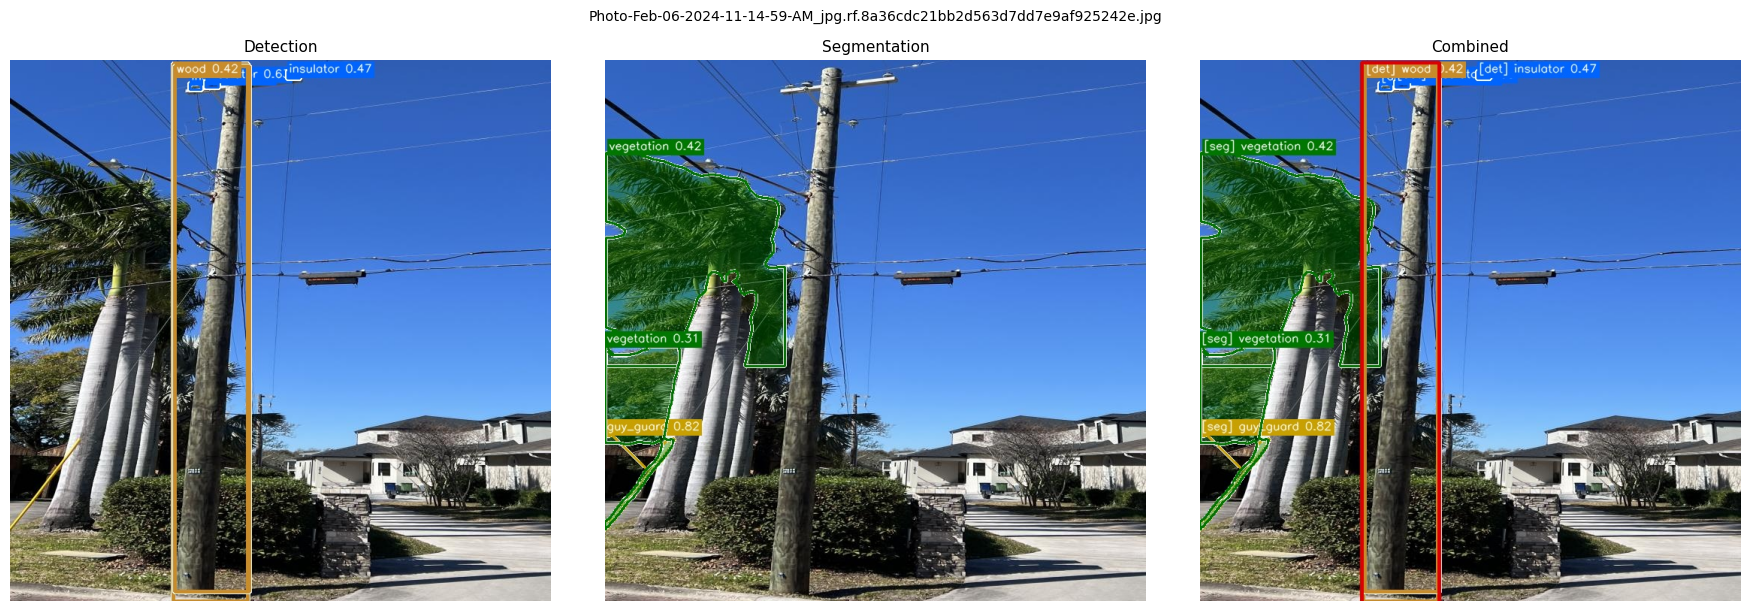


Processing: Photo-Feb-06-2024-11-30-13-AM_jpg.rf.e9b7d9ef457e7ca45f221f05e3c9a05a.jpg
  detections=2  poles=1  segments=3  encroachments=0
  Pole 0 (composite 0.85) → clear


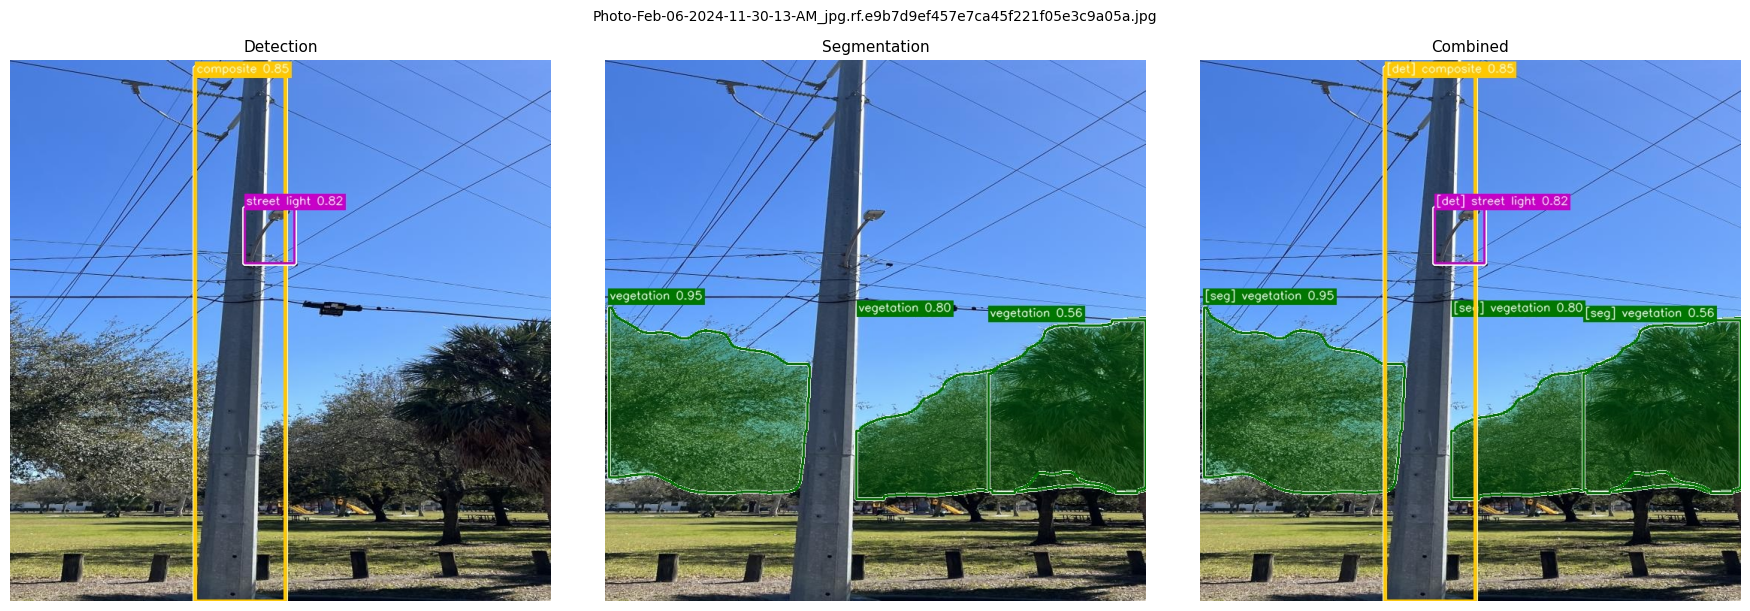


Processing: bdb280a6-53a6-4035-a001-c47825d5e0fa_jpg.rf.dc4c6c43862cbf34283ff94728599396.jpg
  detections=2  poles=1  segments=1  encroachments=1
  Pole 1 (wood 0.93) → ENCROACHMENT


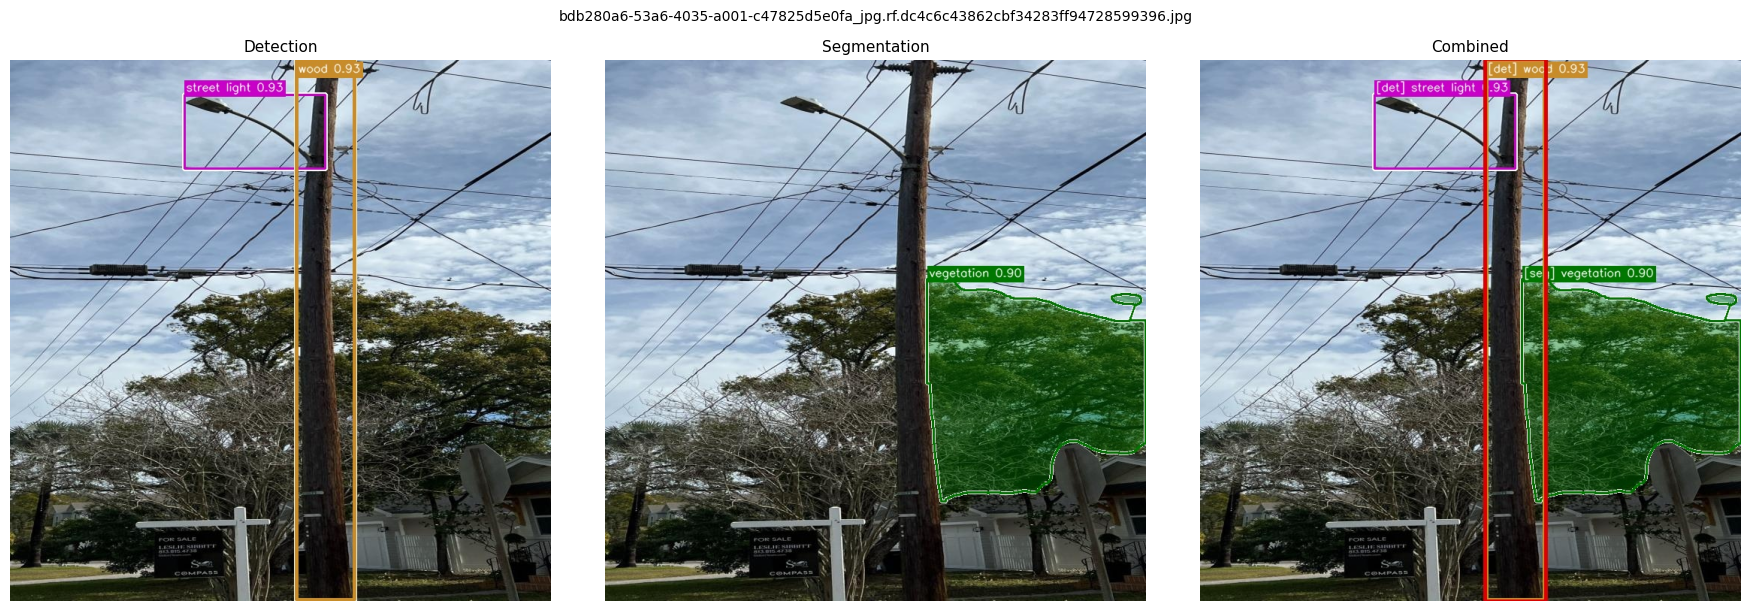


Done. Processed 3 images.


In [129]:
all_results = []

for img_path in selected_paths:
    print(f"\n{'='*60}")
    print(f"Processing: {img_path.name}")

    # ── Load image & run inference ────────────────────────────────
    img_bgr = cv2.imread(str(img_path))
    H, W = img_bgr.shape[:2]
    det_res = detect_model(img_path, conf=CONF, verbose=False)[0]
    seg_res = seg_model(img_path,    conf=CONF, verbose=False)[0]

    # ── Parse & filter ────────────────────────────────────────────
    all_detections = [d for d in parse_detections(det_res, DETECT_CLASSES)
                      if d["class"] not in DET_IGNORE_CLASSES]
    poles    = [d for d in all_detections if d["class_id"] in POLE_CLASS_IDS]
    segments = parse_segments(seg_res, H, W, SEG_CLASSES)
    compute_encroachment(poles, segments, ENCROACHMENT_THRESHOLD)

    n_enc = sum(p["encroachment_detected"] for p in poles)
    print(f"  detections={len(all_detections)}  poles={len(poles)}  "
          f"segments={len(segments)}  encroachments={n_enc}")
    for pole in poles:
        status = "ENCROACHMENT" if pole["encroachment_detected"] else "clear"
        print(f"  Pole {pole['id']} ({pole['class']} {pole['confidence']:.2f}) → {status}")

    # ── Build JSON ────────────────────────────────────────────────
    seg_output = [{k: v for k, v in s.items() if k != "binary_mask"} for s in segments]
    result = {
        "image": str(img_path),
        "output_detection":    str(OUTPUT_DIR / (img_path.stem + "_detection.jpg")),
        "output_segmentation": str(OUTPUT_DIR / (img_path.stem + "_segmentation.jpg")),
        "output_combined":     str(OUTPUT_DIR / (img_path.stem + "_combined.jpg")),
        "poles": poles,
        "segments": seg_output,
        "all_detections": all_detections,
        "summary": {
            "total_poles":               len(poles),
            "poles_with_encroachment":   n_enc,
            "total_vegetation_segments": sum(1 for s in segments if s["class"] == "vegetation"),
            "total_guy_guard_segments":  sum(1 for s in segments if s["class"] == "guy_guard"),
        },
    }
    json_path = OUTPUT_DIR / (img_path.stem + "_encroachment.json")
    json_path.write_text(json.dumps(result, indent=2))
    all_results.append(result)

    # ── Image 1: Detection only ───────────────────────────────────
    det_canvas = img_bgr.copy()
    for det in all_detections:
        b = det["bbox"]
        color = DET_COLORS.get(det["class"], (200, 200, 200))
        thick = 3 if det["class_id"] in POLE_CLASS_IDS else 2
        cv2.rectangle(det_canvas, (b["x1"]-1, b["y1"]-1), (b["x2"]+1, b["y2"]+1), (255,255,255), thick+1)
        cv2.rectangle(det_canvas, (b["x1"], b["y1"]), (b["x2"], b["y2"]), color, thick)
        draw_label(det_canvas, f"{det['class']} {det['confidence']:.2f}",
                   b["x1"], b["y1"], fg=(255,255,255), bg=color)
    det_path = OUTPUT_DIR / (img_path.stem + "_detection.jpg")
    cv2.imwrite(str(det_path), det_canvas)

    # ── Image 2: Segmentation only ────────────────────────────────
    seg_canvas = img_bgr.copy()
    seg_ov = img_bgr.copy()
    for seg in segments:
        fill = SEG_FILL.get(seg["class"], (100,100,100))
        cv2.fillPoly(seg_ov, [np.array(seg["polygon"], dtype=np.int32)], fill)
    cv2.addWeighted(seg_ov, 0.4, seg_canvas, 0.6, 0, seg_canvas)
    for seg in segments:
        fill = SEG_FILL.get(seg["class"], (100,100,100))
        poly = np.array(seg["polygon"], dtype=np.int32)
        cv2.polylines(seg_canvas, [poly], True, (255,255,255), 3)
        cv2.polylines(seg_canvas, [poly], True, fill, 2)
        draw_label(seg_canvas, f"{seg['class']} {seg['confidence']:.2f}",
                   seg["bbox"]["x1"], seg["bbox"]["y1"], fg=(255,255,255), bg=fill)
    seg_path = OUTPUT_DIR / (img_path.stem + "_segmentation.jpg")
    cv2.imwrite(str(seg_path), seg_canvas)

    # ── Image 3: Combined ─────────────────────────────────────────
    combined = img_bgr.copy()
    comb_ov  = img_bgr.copy()
    for seg in segments:
        fill = SEG_FILL.get(seg["class"], (100,100,100))
        cv2.fillPoly(comb_ov, [np.array(seg["polygon"], dtype=np.int32)], fill)
    cv2.addWeighted(comb_ov, 0.4, combined, 0.6, 0, combined)
    for seg in segments:
        fill = SEG_FILL.get(seg["class"], (100,100,100))
        poly = np.array(seg["polygon"], dtype=np.int32)
        cv2.polylines(combined, [poly], True, (255,255,255), 3)
        cv2.polylines(combined, [poly], True, fill, 2)
        draw_label(combined, f"[seg] {seg['class']} {seg['confidence']:.2f}",
                   seg["bbox"]["x1"], seg["bbox"]["y1"], fg=(255,255,255), bg=fill)
    for det in all_detections:
        b = det["bbox"]
        color = DET_COLORS.get(det["class"], (200, 200, 200))
        thick = 3 if det["class_id"] in POLE_CLASS_IDS else 2
        cv2.rectangle(combined, (b["x1"]-1, b["y1"]-1), (b["x2"]+1, b["y2"]+1), (255,255,255), thick+1)
        cv2.rectangle(combined, (b["x1"], b["y1"]), (b["x2"], b["y2"]), color, thick)
        draw_label(combined, f"[det] {det['class']} {det['confidence']:.2f}",
                   b["x1"], b["y1"], fg=(255,255,255), bg=color)
    for pole in poles:
        if pole["encroachment_detected"]:
            b = pole["bbox"]
            cv2.rectangle(combined, (b["x1"]-2, b["y1"]-2), (b["x2"]+2, b["y2"]+2), ENCROACHMENT_COLOR, 4)
            draw_label(combined, "ENCROACHMENT", b["x1"], b["y2"]+30, fg=(255,255,255), bg=ENCROACHMENT_COLOR)
    combined_path = OUTPUT_DIR / (img_path.stem + "_combined.jpg")
    cv2.imwrite(str(combined_path), combined)

    # ── Display 1×3 grid ─────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle(img_path.name, fontsize=10, y=1.01)
    for ax, path, title in zip(
        axes,
        [det_path, seg_path, combined_path],
        ["Detection", "Segmentation", "Combined"],
    ):
        ax.imshow(cv2.cvtColor(cv2.imread(str(path)), cv2.COLOR_BGR2RGB))
        ax.set_title(title, fontsize=11)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

print(f"\nDone. Processed {len(all_results)} images.")

## Summary

Processed 3 images — encroachment detected in 2.
  Photo-Feb-06-2024-11-14-59-AM_jpg.rf.8a36cdc21bb2d563d7dd7e9af925242e.jpg  →  1 encroachment(s)
  Photo-Feb-06-2024-11-30-13-AM_jpg.rf.e9b7d9ef457e7ca45f221f05e3c9a05a.jpg  →  clear
  bdb280a6-53a6-4035-a001-c47825d5e0fa_jpg.rf.dc4c6c43862cbf34283ff94728599396.jpg  →  1 encroachment(s)
Detection image  → output\bdb280a6-53a6-4035-a001-c47825d5e0fa_jpg.rf.dc4c6c43862cbf34283ff94728599396_detection.jpg


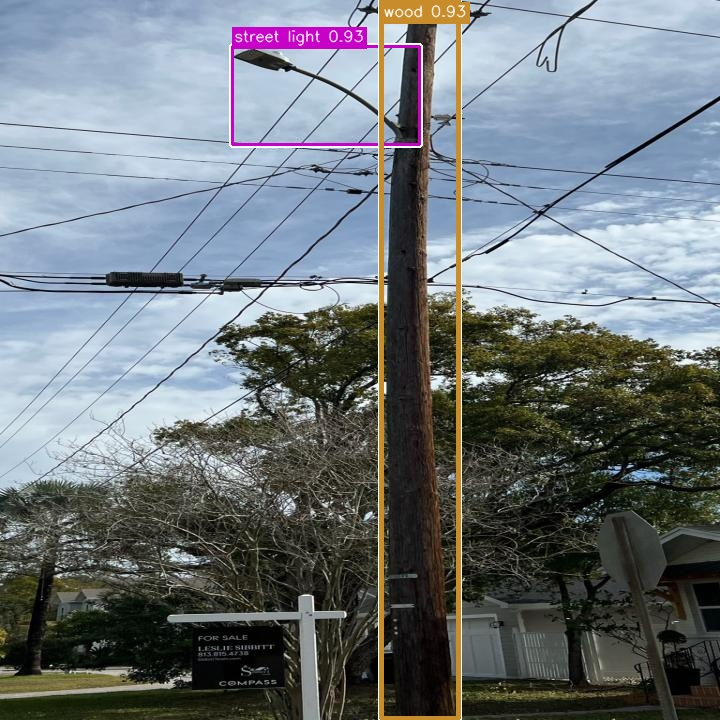

Segmentation image → output\bdb280a6-53a6-4035-a001-c47825d5e0fa_jpg.rf.dc4c6c43862cbf34283ff94728599396_segmentation.jpg


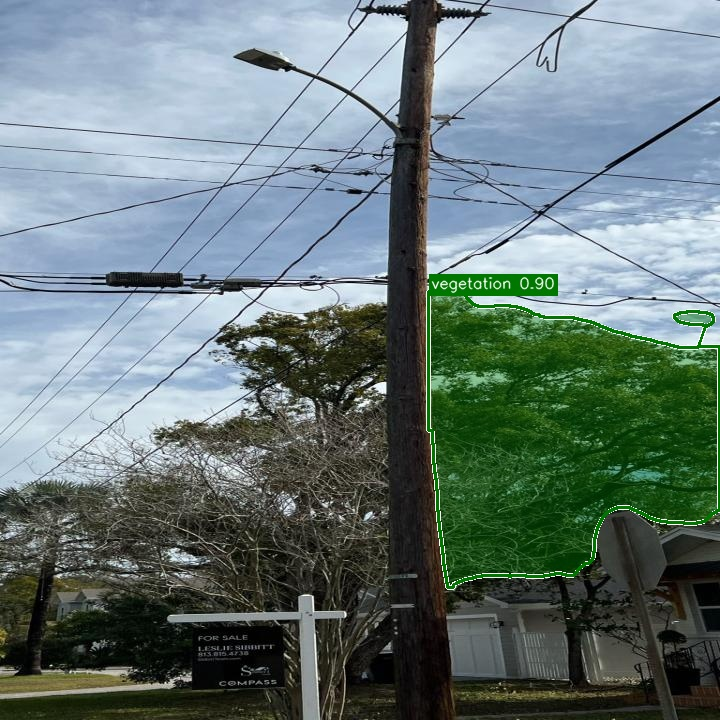

Combined image     → output\bdb280a6-53a6-4035-a001-c47825d5e0fa_jpg.rf.dc4c6c43862cbf34283ff94728599396_combined.jpg


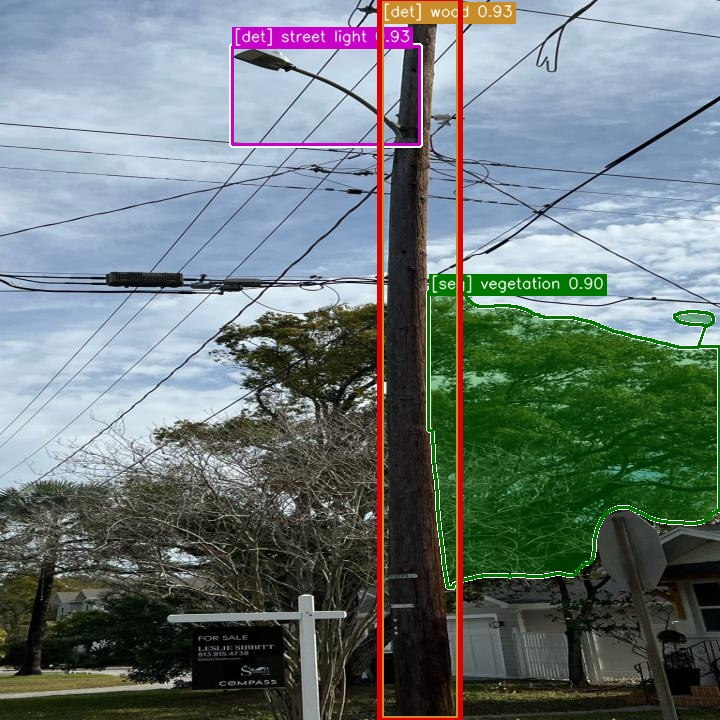

In [130]:
# ── Colour palette ───────────────────────────────────────────────────────────
n_enc = sum(any(p["encroachment_detected"] for p in r["poles"]) for r in all_results)
print(f"Processed {len(all_results)} images — encroachment detected in {n_enc}.")
for r in all_results:
    fname = Path(r["image"]).name
    enc = [p for p in r["poles"] if p["encroachment_detected"]]
    status = f"{len(enc)} encroachment(s)" if enc else "clear"
    print(f"  {fname}  →  {status}")

# Segmentation mask fill colours — darker so detection boxes stand out on top
SEG_FILL = {
    "vegetation": (  0, 120,   0),   # dark green
    "guy_guard":  (  0, 160, 200),   # teal
}
ENCROACHMENT_COLOR = (0, 0, 220)   # red


def draw_label(img, text, x, y, fg=(255, 255, 255), bg=(0, 0, 0)):
    """Draw text with a filled background rectangle so it's always readable."""
    (tw, th), baseline = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
    y = max(y, th + baseline + 4)   # keep label inside image top edge
    cv2.rectangle(img, (x, y - th - baseline - 2), (x + tw + 4, y + 2), bg, -1)
    cv2.putText(img, text, (x + 2, y - baseline),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, fg, 1, cv2.LINE_AA)


# ─────────────────────────────────────────────────────────────────────────────
# Image 1: Detection model only — all bounding boxes, no seg masks
# ─────────────────────────────────────────────────────────────────────────────
det_canvas = img_bgr.copy()

for det in all_detections:
    b      = det["bbox"]
    color  = DET_COLORS.get(det["class"], (200, 200, 200))
    thick  = 3 if det["class_id"] in POLE_CLASS_IDS else 2
    cv2.rectangle(det_canvas,
                  (b["x1"] - 1, b["y1"] - 1), (b["x2"] + 1, b["y2"] + 1),
                  (255, 255, 255), thick + 1)
    cv2.rectangle(det_canvas, (b["x1"], b["y1"]), (b["x2"], b["y2"]), color, thick)
    draw_label(det_canvas, f"{det['class']} {det['confidence']:.2f}",
               b["x1"], b["y1"], fg=(255, 255, 255), bg=color)

det_path = OUTPUT_DIR / (img_path.stem + "_detection.jpg")
cv2.imwrite(str(det_path), det_canvas)
print(f"Detection image  → {det_path}")
display(IPImage(filename=str(det_path)))


# ─────────────────────────────────────────────────────────────────────────────
# Image 2: Segmentation model only — filled masks + contours, no det bboxes
# ─────────────────────────────────────────────────────────────────────────────
seg_canvas = img_bgr.copy()
seg_overlay = img_bgr.copy()

for seg in segments:
    fill = SEG_FILL.get(seg["class"], (100, 100, 100))
    poly = np.array(seg["polygon"], dtype=np.int32)
    cv2.fillPoly(seg_overlay, [poly], fill)

cv2.addWeighted(seg_overlay, 0.4, seg_canvas, 0.6, 0, seg_canvas)

for seg in segments:
    fill = SEG_FILL.get(seg["class"], (100, 100, 100))
    poly = np.array(seg["polygon"], dtype=np.int32)
    cv2.polylines(seg_canvas, [poly], isClosed=True, color=(255, 255, 255), thickness=3)
    cv2.polylines(seg_canvas, [poly], isClosed=True, color=fill, thickness=2)
    draw_label(seg_canvas, f"{seg['class']} {seg['confidence']:.2f}",
               seg["bbox"]["x1"], seg["bbox"]["y1"], fg=(255, 255, 255), bg=fill)

seg_path = OUTPUT_DIR / (img_path.stem + "_segmentation.jpg")
cv2.imwrite(str(seg_path), seg_canvas)
print(f"Segmentation image → {seg_path}")
display(IPImage(filename=str(seg_path)))


# ─────────────────────────────────────────────────────────────────────────────
# Image 3: Combined — seg masks + all det bboxes + encroachment highlights
# ─────────────────────────────────────────────────────────────────────────────
combined = img_bgr.copy()
combined_overlay = img_bgr.copy()

for seg in segments:
    fill = SEG_FILL.get(seg["class"], (100, 100, 100))
    poly = np.array(seg["polygon"], dtype=np.int32)
    cv2.fillPoly(combined_overlay, [poly], fill)

cv2.addWeighted(combined_overlay, 0.4, combined, 0.6, 0, combined)

for seg in segments:
    fill = SEG_FILL.get(seg["class"], (100, 100, 100))
    poly = np.array(seg["polygon"], dtype=np.int32)
    cv2.polylines(combined, [poly], isClosed=True, color=(255, 255, 255), thickness=3)
    cv2.polylines(combined, [poly], isClosed=True, color=fill, thickness=2)
    draw_label(combined, f"[seg] {seg['class']} {seg['confidence']:.2f}",
               seg["bbox"]["x1"], seg["bbox"]["y1"], fg=(255, 255, 255), bg=fill)

for det in all_detections:
    b      = det["bbox"]
    color  = DET_COLORS.get(det["class"], (200, 200, 200))
    thick  = 3 if det["class_id"] in POLE_CLASS_IDS else 2
    cv2.rectangle(combined,
                  (b["x1"] - 1, b["y1"] - 1), (b["x2"] + 1, b["y2"] + 1),
                  (255, 255, 255), thick + 1)
    cv2.rectangle(combined, (b["x1"], b["y1"]), (b["x2"], b["y2"]), color, thick)
    draw_label(combined, f"[det] {det['class']} {det['confidence']:.2f}",
               b["x1"], b["y1"], fg=(255, 255, 255), bg=color)

for pole in poles:
    if pole["encroachment_detected"]:
        b = pole["bbox"]
        cv2.rectangle(combined,
                      (b["x1"] - 2, b["y1"] - 2), (b["x2"] + 2, b["y2"] + 2),
                      ENCROACHMENT_COLOR, 4)
        draw_label(combined, "ENCROACHMENT",
                   b["x1"], b["y2"] + 30, fg=(255, 255, 255), bg=ENCROACHMENT_COLOR)

combined_path = OUTPUT_DIR / (img_path.stem + "_combined.jpg")
cv2.imwrite(str(combined_path), combined)
print(f"Combined image     → {combined_path}")
display(IPImage(filename=str(combined_path)))